# Notebook 1: Data Understanding and Preprocessing
## Healthcare Symptom Pattern Discovery — Task 1
**Objective:** Load and explore the Disease-Symptom dataset, clean it,
and encode symptoms into a binary patient × symptom feature matrix.

**Input :** `dataset.csv`  
**Output:** `task1_encoded.csv` → fed into Notebook 2


In [22]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd          # tabular data manipulation
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns        # statistical visualisation
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
print("All libraries imported successfully.")


All libraries imported successfully.


In [23]:
# ── Load raw dataset ────────────────────────────────────────────────────────
# The Kaggle 'Disease Symptom Description' dataset has 4920 rows.
# Each row = one patient record.  Columns: Disease, Symptom_1 … Symptom_17.
# Symptoms are stored across multiple columns because each patient may have
# a different number of symptoms; unused slots are NaN.

df_raw = pd.read_csv('..//Dataset/dataset.csv')

print("=== Dataset Shape ===")
print(f"Rows (patient records): {df_raw.shape[0]}")
print(f"Columns:                {df_raw.shape[1]}")
print()
print("=== Column Names ===")
print(df_raw.columns.tolist())
print()
print("=== First 5 Rows ===")
display(df_raw.head())


=== Dataset Shape ===
Rows (patient records): 4920
Columns:                18

=== Column Names ===
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

=== First 5 Rows ===


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# ── Data types and missing values ───────────────────────────────────────────
# Understanding data types confirms all symptom columns are object (string).
# Missing values (NaN) simply mean 'no symptom was recorded in that slot'.

print("=== Data Types ===")
print(df_raw.dtypes.to_string())
print()
print("=== Missing Value Count per Column ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())
print(f"\nTotal NaN values: {df_raw.isnull().sum().sum():,}")


=== Data Types ===
Disease       object
Symptom_1     object
Symptom_2     object
Symptom_3     object
Symptom_4     object
Symptom_5     object
Symptom_6     object
Symptom_7     object
Symptom_8     object
Symptom_9     object
Symptom_10    object
Symptom_11    object
Symptom_12    object
Symptom_13    object
Symptom_14    object
Symptom_15    object
Symptom_16    object
Symptom_17    object

=== Missing Value Count per Column ===
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848

Total NaN values: 46,992


In [25]:
# ── Disease distribution ────────────────────────────────────────────────────
# Count records per disease to verify dataset balance.
# The original Kaggle dataset has exactly 120 records per disease class.

disease_counts = df_raw['Disease'].value_counts()
print(f"Unique diseases: {disease_counts.shape[0]}")
print(f"Records per disease (min / max): {disease_counts.min()} / {disease_counts.max()}")
print()
print(disease_counts.to_string())


Unique diseases: 41
Records per disease (min / max): 120 / 120

Disease
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                        

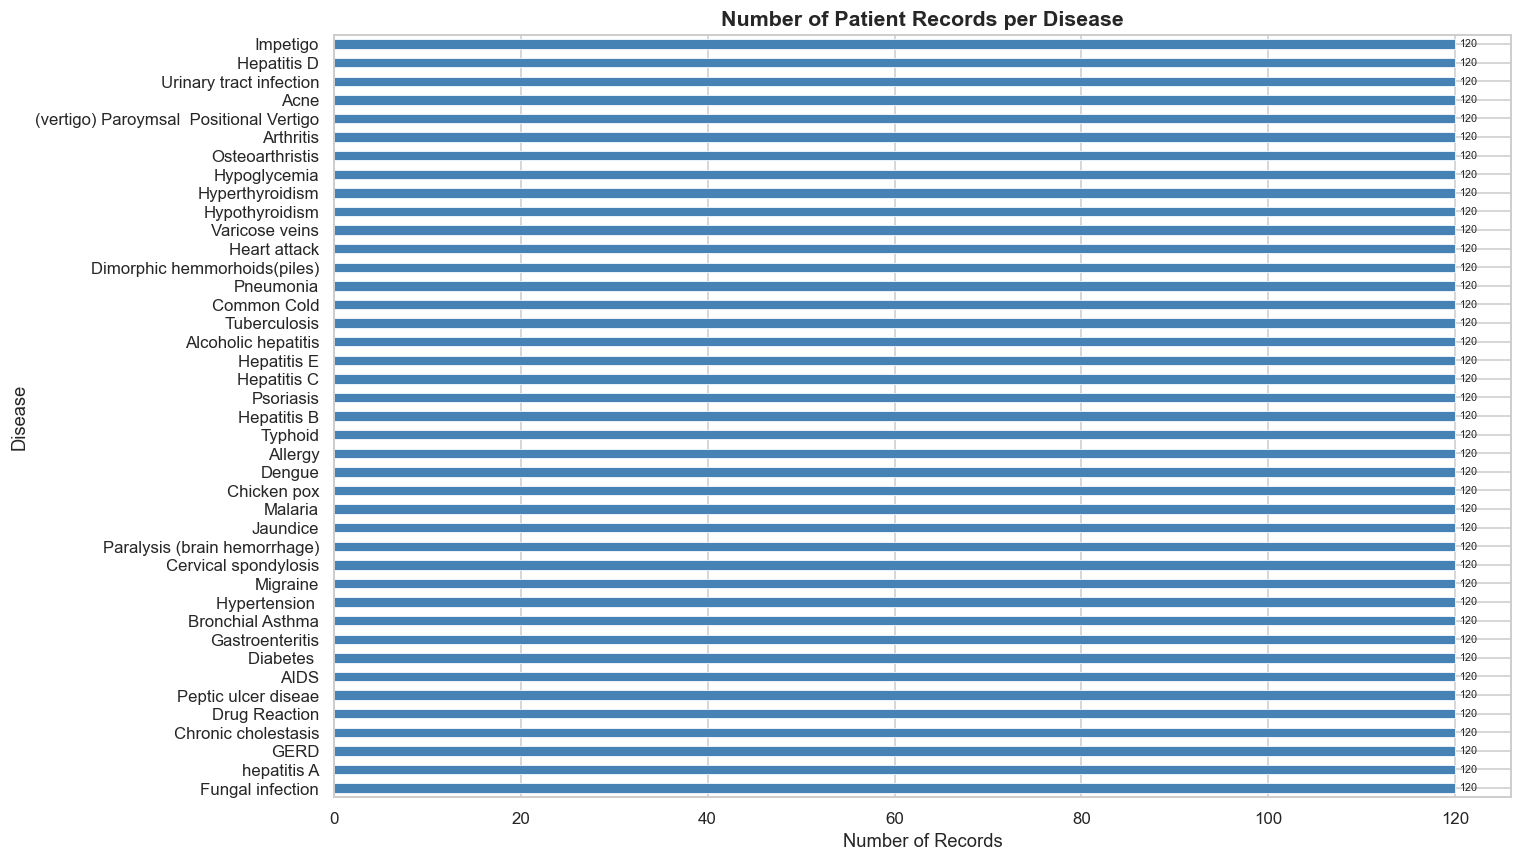

Figure saved → task1_disease_distribution.png


In [26]:
# ── Bar chart: records per disease ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
disease_counts.sort_values().plot(kind='barh', ax=ax,
                                   color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Number of Patient Records per Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Records')
ax.set_ylabel('Disease')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig('..//Result_NB1/task1_disease_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved → task1_disease_distribution.png")


In [27]:
# ── Melt wide format → long format ──────────────────────────────────────────
# Problem: symptoms are spread across 17 columns. We need them in one column.
# Solution: pandas.melt() stacks all symptom columns into a single 'symptom'
# column, creating one row per (patient_record, symptom) pair.
# NaN rows (empty slots) are dropped after melting.

df_reset = df_raw.reset_index().rename(columns={'index': 'patient_id'})
symptom_cols = [c for c in df_reset.columns if c.startswith('Symptom_')]

df_long = df_reset.melt(
    id_vars=['patient_id', 'Disease'],   # keep these columns as identifiers
    value_vars=symptom_cols,             # melt all symptom slot columns
    var_name='slot',                     # resulting column for slot names
    value_name='symptom'                 # resulting column for symptom values
).dropna(subset=['symptom'])             # drop rows where no symptom was listed

# Standardise symptom strings: lowercase, trim whitespace, replace spaces with _
df_long['symptom'] = (
    df_long['symptom']
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print(f"Long-format rows after melt: {df_long.shape[0]:,}")
print(f"Unique symptoms detected:    {df_long['symptom'].nunique()}")
print()
print(df_long.head(8).to_string(index=False))


Long-format rows after melt: 36,648
Unique symptoms detected:    131

 patient_id          Disease      slot   symptom
          0 Fungal infection Symptom_1   itching
          1 Fungal infection Symptom_1 skin_rash
          2 Fungal infection Symptom_1   itching
          3 Fungal infection Symptom_1   itching
          4 Fungal infection Symptom_1   itching
          5 Fungal infection Symptom_1 skin_rash
          6 Fungal infection Symptom_1   itching
          7 Fungal infection Symptom_1   itching


In [28]:
# ── Symptom frequency analysis ───────────────────────────────────────────────
# Frequency = how many times each symptom appears across ALL patient records.
# High-frequency symptoms are clinically prevalent across many diseases.

symptom_freq = df_long['symptom'].value_counts()
print("=== Top 30 Most Frequent Symptoms ===")
print(symptom_freq.head(30).to_string())


=== Top 30 Most Frequent Symptoms ===
symptom
fatigue                         1932
vomiting                        1914
high_fever                      1362
loss_of_appetite                1152
nausea                          1146
headache                        1134
abdominal_pain                  1032
yellowish_skin                   912
yellowing_of_eyes                816
chills                           798
skin_rash                        786
malaise                          702
chest_pain                       696
joint_pain                       684
sweating                         678
itching                          678
dark_urine                       570
cough                            564
diarrhoea                        564
muscle_pain                      474
irritability                     474
excessive_hunger                 462
lethargy                         456
weight_loss                      456
breathlessness                   450
mild_fever                   

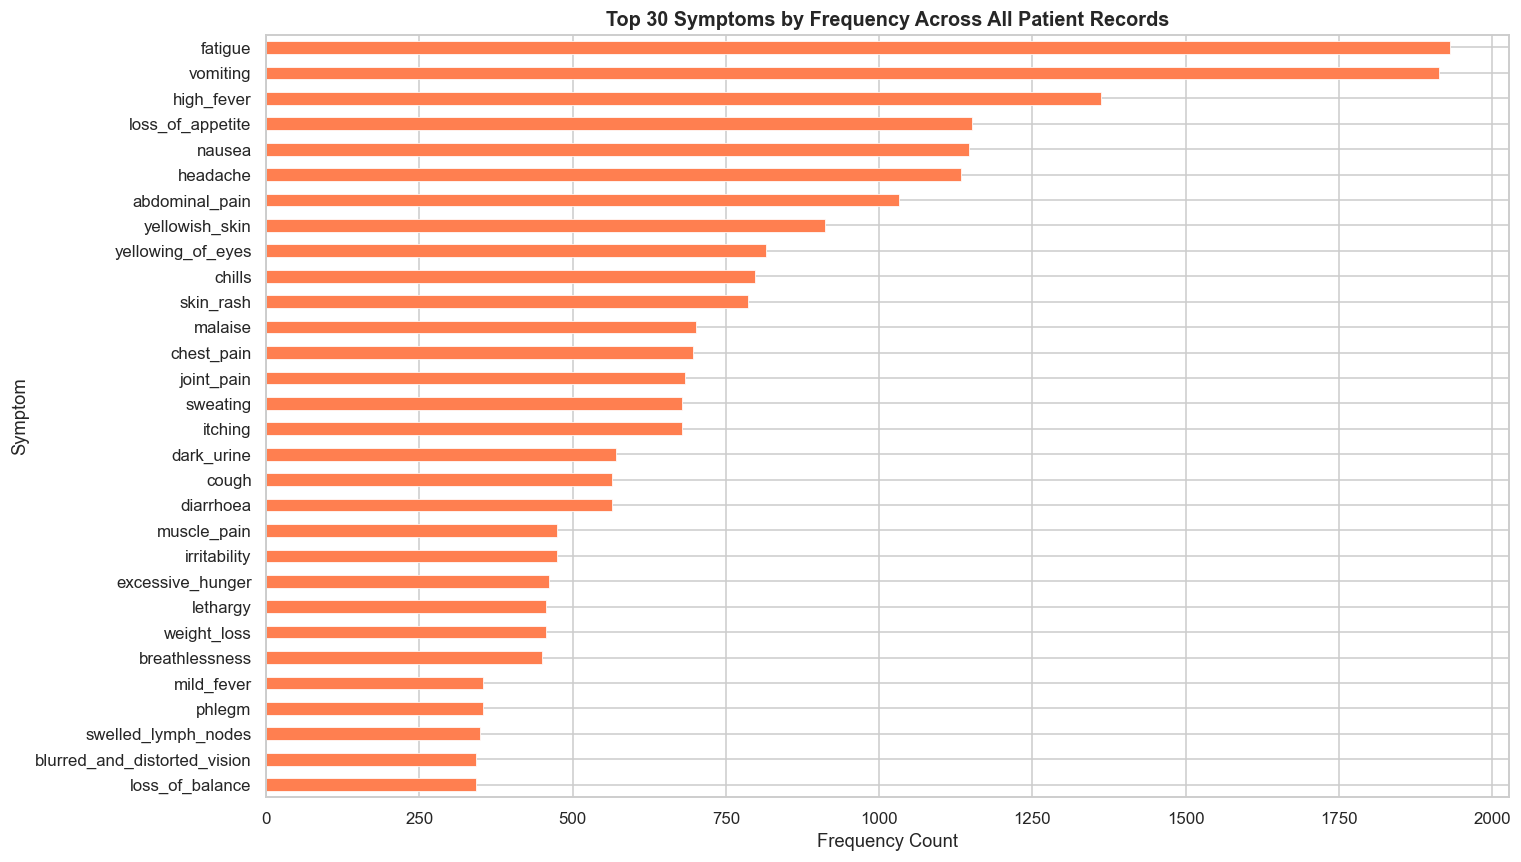

Figure saved → task1_symptom_frequency.png


In [29]:
# ── Horizontal bar chart: top 30 symptoms ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
symptom_freq.head(30).sort_values().plot(
    kind='barh', ax=ax, color='coral', edgecolor='white', linewidth=0.5)
ax.set_title('Top 30 Symptoms by Frequency Across All Patient Records',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency Count')
ax.set_ylabel('Symptom')
plt.tight_layout()
plt.savefig('..//Result_NB1/task1_symptom_frequency.png', bbox_inches='tight')
plt.show()
print("Figure saved → task1_symptom_frequency.png")


In [30]:
# ── Binary Encoding: Build Patient × Symptom Matrix ─────────────────────────
# Each row = one patient record (identified by patient_id).
# Each column = one symptom.
# Value = 1 if the symptom is present for that patient, else 0.
#
# Implementation:
#   groupby(['patient_id','symptom']).size() → counts occurrences (almost always 1)
#   .unstack(fill_value=0)                  → pivot to wide format
#   .clip(upper=1)                          → enforce strict binary (max = 1)

binary_matrix = (
    df_long
    .groupby(['patient_id', 'symptom'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)
)

print(f"Binary matrix shape: {binary_matrix.shape}")
print(f"  → {binary_matrix.shape[0]} patient records")
print(f"  → {binary_matrix.shape[1]} unique symptoms")
print()
print("Sample (first 4 rows, first 6 columns):")
display(binary_matrix.iloc[:4, :6])


Binary matrix shape: (4920, 131)
  → 4920 patient records
  → 131 unique symptoms

Sample (first 4 rows, first 6 columns):


symptom,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety
patient_id,,,,,,
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0


In [31]:
# ── Attach disease label ─────────────────────────────────────────────────────
# We re-attach the Disease column from the original dataframe.
# This label is NOT used during unsupervised learning but is retained
# for post-hoc evaluation of cluster quality in later notebooks.

disease_map = df_reset.set_index('patient_id')['Disease']
binary_matrix['Disease'] = binary_matrix.index.map(disease_map)

print(f"Matrix shape with Disease label: {binary_matrix.shape}")
print("Disease label sample:")
print(binary_matrix['Disease'].value_counts().head(8).to_string())


Matrix shape with Disease label: (4920, 132)
Disease label sample:
Disease
Fungal infection                120
Hepatitis C                     120
Hepatitis E                     120
Alcoholic hepatitis             120
Tuberculosis                    120
Common Cold                     120
Pneumonia                       120
Dimorphic hemmorhoids(piles)    120


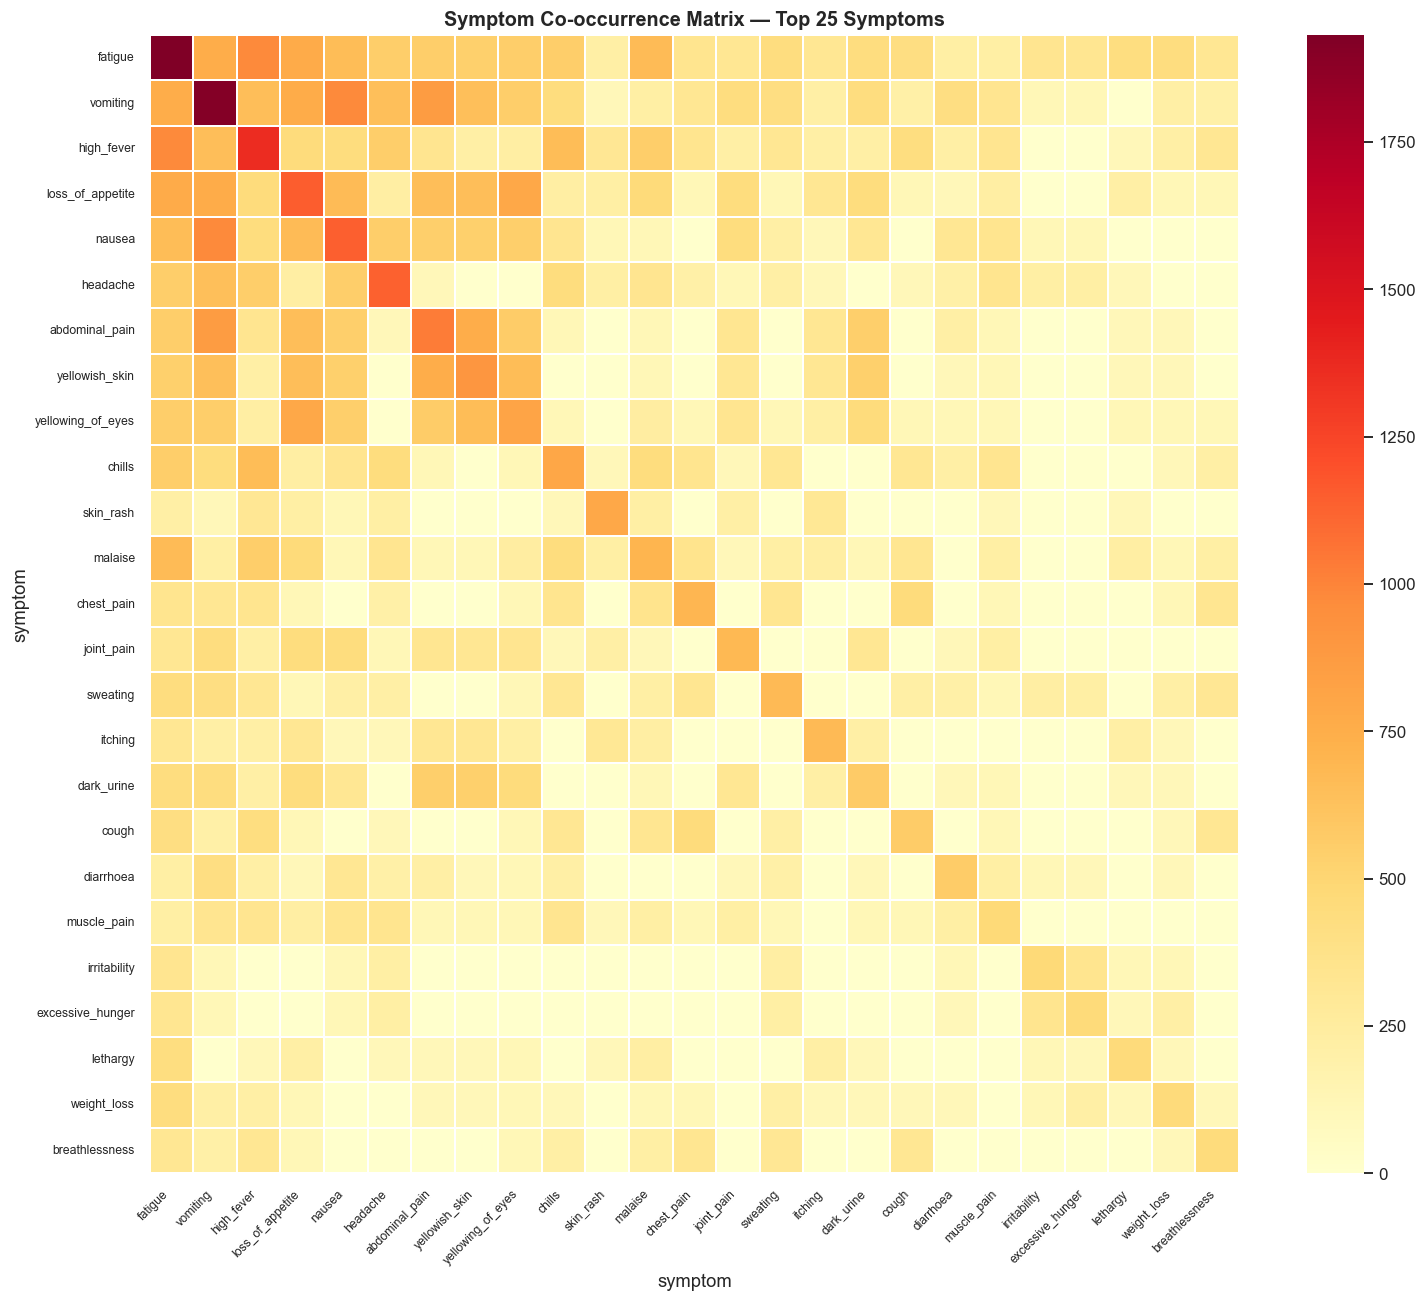

Figure saved → task1_cooccurrence_heatmap.png


In [32]:
# ── Symptom co-occurrence heatmap (top 25 symptoms) ─────────────────────────
# Co-occurrence = how many patients have BOTH symptom A and symptom B.
# High co-occurrence → symptoms tend to appear together → likely same disease.

X_only = binary_matrix.drop(columns=['Disease'])
top25 = symptom_freq.head(25).index.tolist()
co_matrix = X_only[top25].T.dot(X_only[top25])  # matrix multiplication = dot product count

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(co_matrix, cmap='YlOrRd', linewidths=0.3, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Symptom Co-occurrence Matrix — Top 25 Symptoms',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('..//Result_NB1/task1_cooccurrence_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure saved → task1_cooccurrence_heatmap.png")


In [33]:
# ── Summary statistics ──────────────────────────────────────────────────────
X_only = binary_matrix.drop(columns=['Disease'])
symptoms_per_patient = X_only.sum(axis=1)

print("=== Binary Matrix Summary Statistics ===")
print(f"Patient records:            {X_only.shape[0]:,}")
print(f"Unique symptoms (features): {X_only.shape[1]:,}")
print(f"Overall symptom presence rate: {X_only.values.mean()*100:.2f}%")
print(f"Avg symptoms per patient:      {symptoms_per_patient.mean():.2f}")
print(f"Max symptoms for one patient:  {int(symptoms_per_patient.max())}")
print(f"Min symptoms for one patient:  {int(symptoms_per_patient.min())}")
print()
print("Distribution of symptom count per patient:")
print(symptoms_per_patient.value_counts().sort_index().to_string())


=== Binary Matrix Summary Statistics ===
Patient records:            4,920
Unique symptoms (features): 131
Overall symptom presence rate: 5.69%
Avg symptoms per patient:      7.45
Max symptoms for one patient:  17
Min symptoms for one patient:  3

Distribution of symptom count per patient:
3     348
4     858
5     780
6     666
7     324
8     252
9     180
10    318
11    450
12    240
13    198
14     66
15     48
16    120
17     72


In [34]:
# ── Save encoded matrix to CSV ───────────────────────────────────────────────
# This file becomes the input for Notebook 2.
# The 'Disease' column is preserved for evaluation purposes only.

output_path = '..//Result_NB1/task1_encoded.csv'
binary_matrix.to_csv(output_path)

print(f"✅ Saved: {output_path}")
print(f"   Shape: {binary_matrix.shape}")
print("\n→ Next step: Run Notebook 2 (Feature Engineering & Modelling)")


✅ Saved: ..//Result_NB1/task1_encoded.csv
   Shape: (4920, 132)

→ Next step: Run Notebook 2 (Feature Engineering & Modelling)
